# NYC Airbnb Listings: Pricing, Supply, and Guest Engagement

**Portfolio analysis by Ntokozo Hlongwane**  
**Tools:** Python, pandas, Matplotlib, Seaborn  
**Unit of analysis:** Listing records in the supplied cross-sectional extract

This project turns a raw NYC Airbnb listings file into a reproducible exploratory analysis for market benchmarking. It focuses on where listing records are concentrated, how typical prices differ by borough and room type, and whether price is strongly associated with engagement or availability measures.

## Executive Summary

- The cleaned analytical sample contains **20,724 listing records** after removing **12 exact duplicates** and excluding **34 records** missing key analytical fields.
- **Manhattan and Brooklyn account for 75.9%** of usable records, making them the centre of the observed supply.
- The citywide median nightly price is **$125**. Manhattan has the highest borough median (**$150**), while Bronx is lowest (**$89**).
- Entire homes/apartments have a median price of **$160**, twice the **$80** median for private rooms.
- **85.1%** of records require at least 30 nights, so this extract is heavily oriented toward longer minimum stays.
- Price has a moderate positive Spearman association with bed count (**ρ = 0.447**) but almost no association with availability (**ρ = 0.038**) or reviews in the last 12 months (**ρ = 0.022**).
- A major data-quality issue affects the listing identifier: **38.8% of IDs were shortened into scientific notation**, so ID-based unique-listing counts are unreliable.

## Context & Methods

### Business problem

A market analyst, prospective host, or traveller needs a reliable summary of the observed NYC Airbnb market without allowing extreme prices or corrupted identifiers to distort the story.

### Questions

1. Where are listing records concentrated across NYC boroughs and room types?
2. How do typical nightly prices differ by borough and room type?
3. Which established neighbourhoods combine meaningful listing volume with higher or lower median prices?
4. How strongly is price associated with capacity, availability, ratings, and review activity?

### Key assumptions

- Each row is treated as a **listing record**, not a guaranteed unique listing, because many IDs lost precision during export.
- Medians and interquartile ranges are the main price statistics because the price distribution is strongly right-skewed.
- The **99th-percentile price threshold** is used only to make the distribution chart readable. Group medians retain all valid prices.
- `availability_365` is calendar availability, not verified occupancy or demand.

## Data

### 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")

BLUE = "#2463A6"
GOLD = "#D6A62E"
ORANGE = "#D97732"
OLIVE = "#748B3D"
PINK = "#C75C8A"
INK = "#24313F"
GREY = "#7A8793"

BOROUGH_PALETTE = {
    "Manhattan": BLUE,
    "Brooklyn": GOLD,
    "Queens": ORANGE,
    "Bronx": OLIVE,
    "Staten Island": PINK,
}

DATA_PATH = Path("data/datasets.csv")
IMAGE_DIR = Path("images")
IMAGE_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Expected data/datasets.csv. Run the notebook from the project root."
    )

### 2. Load the source file

In [2]:
# Read identifiers as strings to avoid introducing additional numeric rounding.
raw_data = pd.read_csv(
    DATA_PATH,
    dtype={"id": "string", "host_id": "string"},
)

print(f"Rows: {raw_data.shape[0]:,}")
print(f"Columns: {raw_data.shape[1]}")
display(raw_data.head(3))

Rows: 20,770
Columns: 22


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1312228,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.68,-73.96,Private room,55.00,30.00,3.00,20/12/15,0.03,1.00,0.00,0.00,No License,5,1,1,Not specified
1,45277537,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.77,-73.99,Entire home/apt,144.00,30.00,9.00,01/05/23,0.24,139.00,364.00,2.00,No License,4.67,2,1,1
2,9.71E+17,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.75,-73.99,Entire home/apt,187.00,2.00,6.00,18/12/23,1.67,1.00,343.00,6.00,Exempt,4.17,1,2,1


### 3. Profile data quality

In [3]:
exact_duplicate_rows = int(raw_data.duplicated().sum())
scientific_id_rows = int(raw_data["id"].str.contains(r"[Ee]\+", na=False).sum())
scientific_id_rate = scientific_id_rows / len(raw_data)

quality_profile = pd.DataFrame(
    [
        ["Raw shape", f"{raw_data.shape[0]:,} rows × {raw_data.shape[1]} columns", "Source inventory"],
        ["Exact duplicate rows", f"{exact_duplicate_rows:,}", "Remove exact copies only"],
        [
            "IDs stored in scientific notation",
            f"{scientific_id_rows:,} ({scientific_id_rate:.1%})",
            "Do not use id as a unique key",
        ],
        ["Missing price", f"{raw_data['price'].isna().sum():,}", "Exclude from price analysis"],
        [
            "Missing location / room type",
            f"{raw_data['room_type'].isna().sum():,}",
            "Exclude from segment analysis",
        ],
        [
            "Price range",
            f"${raw_data['price'].min():,.0f}–${raw_data['price'].max():,.0f}",
            "Use robust statistics and show a bounded distribution",
        ],
    ],
    columns=["Check", "Observed result", "Analytical treatment"],
)

display(quality_profile)

,Check,Observed result,Analytical treatment
0,Raw shape,"20,770 rows × 22 columns",Source inventory
1,Exact duplicate rows,12,Remove exact copies only
2,IDs stored in scientific notation,"8,050 (38.8%)",Do not use id as a unique key
3,Missing price,34,Exclude from price analysis
4,Missing location / room type,7,Exclude from segment analysis
5,Price range,"$10–$100,000",Use robust statistics and show a bounded distr...


**Quality interpretation.** The shortened scientific-notation IDs create collisions between visibly different properties, so deduplicating on `id` would incorrectly delete valid records. Only exact duplicate rows are removed. The unusually high maximum price also makes the mean a poor description of a typical listing; medians are more reliable.

### 4. Clean and engineer analytical fields

In [4]:
data = raw_data.drop_duplicates().copy()

# Trim text fields while preserving missing values.
text_columns = data.select_dtypes(include=["object", "string"]).columns
for column in text_columns:
    data[column] = data[column].astype("string").str.strip()

numeric_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "number_of_reviews_ltm",
    "beds",
]
for column in numeric_columns:
    data[column] = pd.to_numeric(data[column], errors="coerce")

data["rating_numeric"] = pd.to_numeric(data["rating"], errors="coerce")
data["bedrooms_numeric"] = pd.to_numeric(
    data["bedrooms"].replace({"Studio": "0", "Not specified": pd.NA}),
    errors="coerce",
)
data["baths_numeric"] = pd.to_numeric(
    data["baths"].replace({"Not specified": pd.NA}),
    errors="coerce",
)
data["last_review_date"] = pd.to_datetime(
    data["last_review"], format="%d/%m/%y", errors="coerce"
)

key_fields = [
    "price",
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "latitude",
    "longitude",
    "minimum_nights",
    "availability_365",
]
analysis_df = data.dropna(subset=key_fields).copy()
analysis_df["price_per_bed"] = analysis_df["price"] / analysis_df["beds"].replace(0, np.nan)

price_99th_percentile = analysis_df["price"].quantile(0.99)
core_price_df = analysis_df.loc[analysis_df["price"] <= price_99th_percentile].copy()

print(f"Rows after exact deduplication: {len(data):,}")
print(f"Usable analytical rows: {len(analysis_df):,}")
print(f"99th-percentile price threshold: ${price_99th_percentile:,.0f}")
print(f"Rows in bounded price view: {len(core_price_df):,}")

Rows after exact deduplication: 20,758
Usable analytical rows: 20,724
99th-percentile price threshold: $999
Rows in bounded price view: 20,527


### 5. Validate the analytical sample

In [5]:
assert data.duplicated().sum() == 0
assert analysis_df[key_fields].notna().all().all()
assert analysis_df["price"].gt(0).all()
assert analysis_df["beds"].gt(0).all()
assert analysis_df["availability_365"].between(0, 365).all()
assert analysis_df["latitude"].between(40.4, 41.0).all()
assert analysis_df["longitude"].between(-74.4, -73.6).all()

validation_summary = pd.DataFrame(
    {
        "Test": [
            "Exact duplicates removed",
            "Key analysis fields complete",
            "Prices are positive",
            "Bed counts are positive",
            "Availability lies between 0 and 365",
            "Coordinates fall within the NYC-area bounding box",
        ],
        "Status": ["Passed"] * 6,
    }
)
display(validation_summary)

,Test,Status
0,Exact duplicates removed,Passed
1,Key analysis fields complete,Passed
2,Prices are positive,Passed
3,Bed counts are positive,Passed
4,Availability lies between 0 and 365,Passed
5,Coordinates fall within the NYC-area bounding box,Passed


## Results

### 1. Market overview

In [6]:
overview = pd.DataFrame(
    {
        "Metric": [
            "Usable listing records",
            "Median nightly price",
            "Interquartile price range",
            "Entire home / apartment share",
            "Minimum stay of 30+ nights",
            "Median annual availability",
        ],
        "Value": [
            f"{len(analysis_df):,}",
            f"${analysis_df['price'].median():,.0f}",
            f"${analysis_df['price'].quantile(0.25):,.0f}–${analysis_df['price'].quantile(0.75):,.0f}",
            f"{(analysis_df['room_type'].eq('Entire home/apt')).mean():.1%}",
            f"{(analysis_df['minimum_nights'].ge(30)).mean():.1%}",
            f"{analysis_df['availability_365'].median():,.0f} days",
        ],
    }
)
display(overview)

,Metric,Value
0,Usable listing records,"20,724"
1,Median nightly price,$125
2,Interquartile price range,$80–$199
3,Entire home / apartment share,55.6%
4,Minimum stay of 30+ nights,85.1%
5,Median annual availability,214 days


### 2. Listing-record concentration and room-type mix

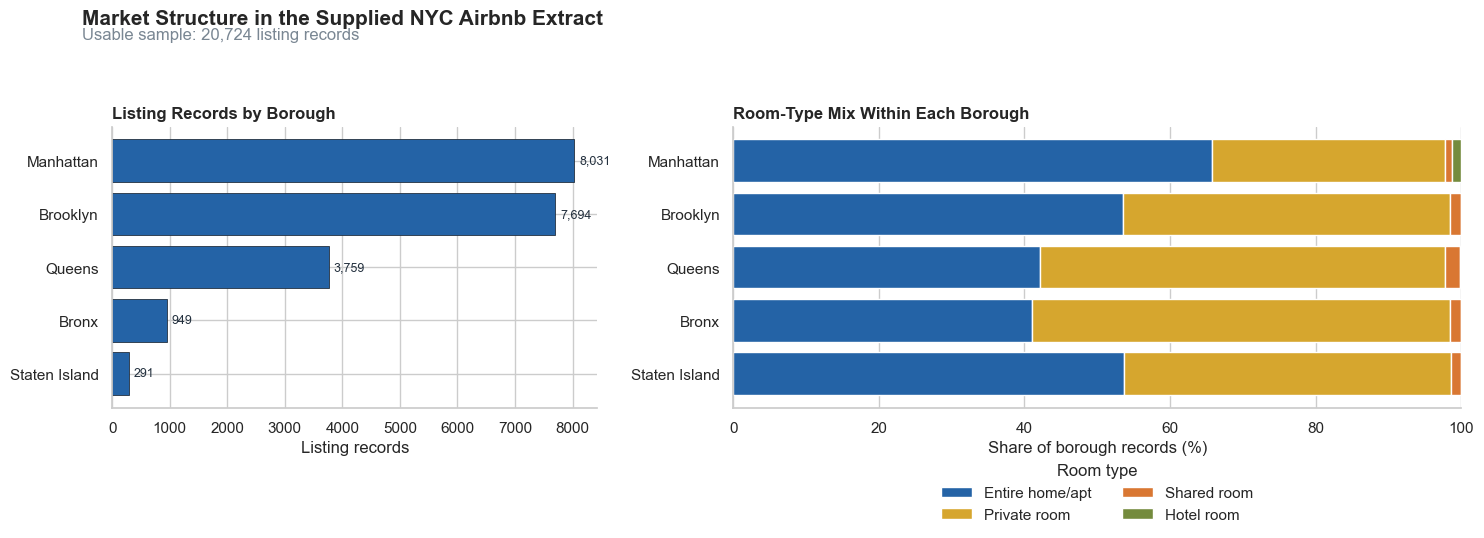

In [7]:
borough_counts = analysis_df["neighbourhood_group"].value_counts().sort_values()
room_mix = (
    pd.crosstab(analysis_df["neighbourhood_group"], analysis_df["room_type"], normalize="index")
    .mul(100)
    .loc[borough_counts.index]
)

room_order = ["Entire home/apt", "Private room", "Shared room", "Hotel room"]
room_colors = [BLUE, GOLD, ORANGE, OLIVE]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [0.9, 1.35]})

axes[0].barh(borough_counts.index, borough_counts.values, color=BLUE, edgecolor=INK, linewidth=0.6)
axes[0].set_title("Listing Records by Borough", loc="left", fontweight="bold")
axes[0].set_xlabel("Listing records")
axes[0].set_ylabel("")
for i, value in enumerate(borough_counts.values):
    axes[0].text(value + 90, i, f"{value:,}", va="center", color=INK, fontsize=9)

left = np.zeros(len(room_mix))
for room, color in zip(room_order, room_colors):
    values = room_mix.get(room, pd.Series(0, index=room_mix.index)).values
    axes[1].barh(room_mix.index, values, left=left, label=room, color=color, edgecolor="white")
    left += values
axes[1].set_title("Room-Type Mix Within Each Borough", loc="left", fontweight="bold")
axes[1].set_xlabel("Share of borough records (%)")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 100)
axes[1].legend(title="Room type", bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=2, frameon=False)

fig.suptitle("Market Structure in the Supplied NYC Airbnb Extract", x=0.06, ha="left", fontsize=15, fontweight="bold")
fig.text(0.06, 0.93, f"Usable sample: {len(analysis_df):,} listing records", color=GREY)
sns.despine(fig=fig)
plt.tight_layout(rect=[0, 0.04, 1, 0.91])
plt.savefig(IMAGE_DIR / "market_structure.png", dpi=180, bbox_inches="tight")
plt.show()

**Interpretation.** Manhattan (8,031 records) and Brooklyn (7,694) jointly contribute **75.9%** of the usable sample. Entire homes/apartments dominate Manhattan, while private rooms make up a larger share in Queens and Bronx. The mix matters: citywide price comparisons can be misleading when boroughs contain different room-type compositions.

### 3. Typical prices by borough and room type

In [8]:
borough_summary = (
    analysis_df.groupby("neighbourhood_group")
    .agg(
        records=("id", "size"),
        median_price=("price", "median"),
        lower_quartile=("price", lambda values: values.quantile(0.25)),
        upper_quartile=("price", lambda values: values.quantile(0.75)),
        median_availability=("availability_365", "median"),
        median_reviews_ltm=("number_of_reviews_ltm", "median"),
    )
    .sort_values("median_price", ascending=False)
)
borough_display = borough_summary.copy()
borough_display["records"] = borough_display["records"].map(lambda value: f"{value:,.0f}")
for column in ["median_price", "lower_quartile", "upper_quartile"]:
    borough_display[column] = borough_display[column].map(lambda value: f"${value:,.0f}")
for column in ["median_availability", "median_reviews_ltm"]:
    borough_display[column] = borough_display[column].map(lambda value: f"{value:,.0f}")
display(borough_display)

,records,median_price,lower_quartile,upper_quartile,median_availability,median_reviews_ltm
neighbourhood_group,,,,,,
Manhattan,"8,031",$150,$100,$244,223,2
Brooklyn,"7,694",$125,$77,$194,182,4
Staten Island,291,$99,$70,$137,261,7
Queens,"3,759",$98,$61,$150,219,5
Bronx,949,$89,$59,$128,279,5


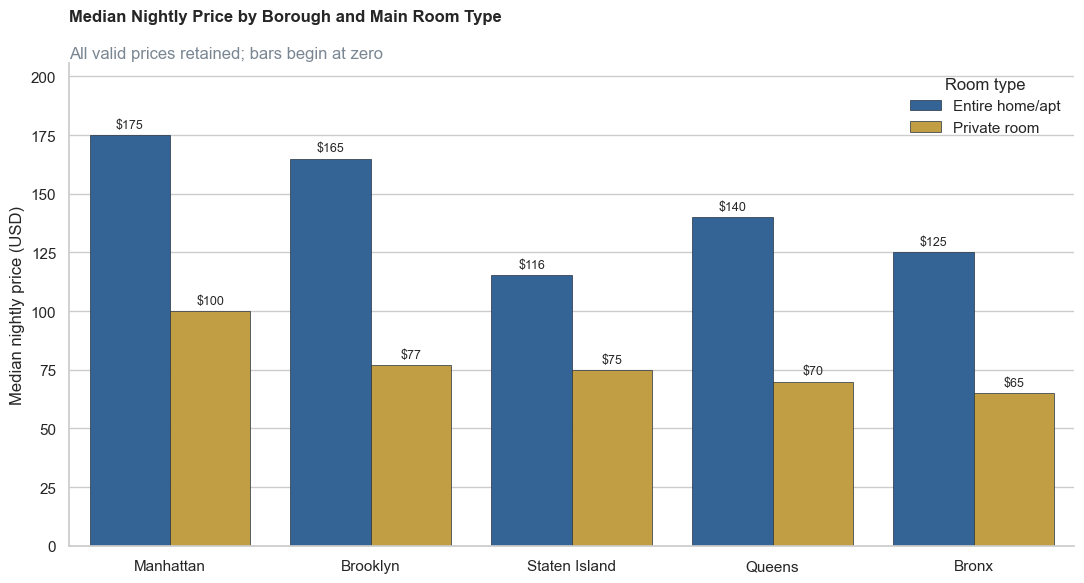

In [9]:
main_room_types = ["Entire home/apt", "Private room"]
borough_order = (
    analysis_df.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False).index
)
price_by_segment = (
    analysis_df.loc[analysis_df["room_type"].isin(main_room_types)]
    .groupby(["neighbourhood_group", "room_type"], as_index=False)
    .agg(median_price=("price", "median"), records=("id", "size"))
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=price_by_segment,
    x="neighbourhood_group",
    y="median_price",
    hue="room_type",
    order=borough_order,
    hue_order=main_room_types,
    palette={"Entire home/apt": BLUE, "Private room": GOLD},
    edgecolor=INK,
    linewidth=0.5,
)
ax.set_title("Median Nightly Price by Borough and Main Room Type", loc="left", fontweight="bold", pad=30)
ax.text(0, 1.01, "All valid prices retained; bars begin at zero", transform=ax.transAxes, color=GREY)
ax.set_xlabel("")
ax.set_ylabel("Median nightly price (USD)")
ax.legend(title="Room type", frameon=False)
for container in ax.containers:
    ax.bar_label(container, labels=[f"${bar.get_height():,.0f}" for bar in container], padding=3, fontsize=9)
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
sns.despine()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "median_price_by_borough_room_type.png", dpi=180, bbox_inches="tight")
plt.show()

**Interpretation.** The citywide median is **$125**, but location and room type materially change the benchmark. Manhattan leads at **$150** overall. Entire homes range from **$115.50 in Staten Island** to **$175 in Manhattan**, while private rooms range from **$65 in Bronx** to **$100 in Manhattan**. A fair pricing comparison should therefore match both borough and room type.

### 4. Price distribution and extreme values

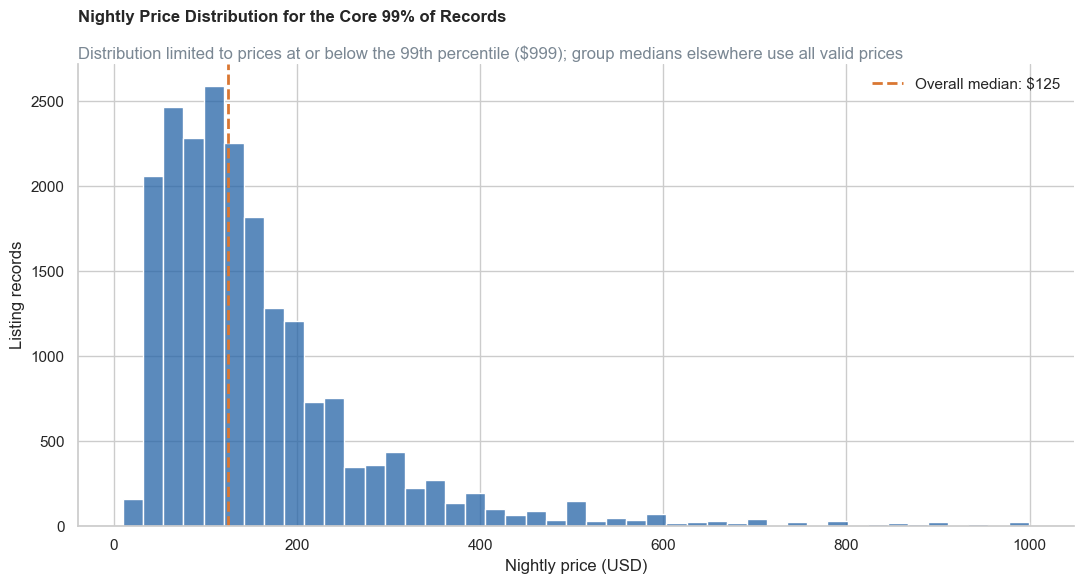

In [13]:
plt.figure(figsize=(11, 6))
ax = sns.histplot(core_price_df, x="price", bins=45, color=BLUE, edgecolor="White")
median_price = analysis_df["price"].median()
ax.axvline(median_price, color=ORANGE, linestyle="--", linewidth=2, label=f"Overall median: ${median_price:,.0f}")
ax.set_title("Nightly Price Distribution for the Core 99% of Records", loc="left", fontweight="bold", pad=30)
ax.text(
    0,
    1.01,
    f"Distribution limited to prices at or below the 99th percentile (${price_99th_percentile:,.0f}); group medians elsewhere use all valid prices",
    transform=ax.transAxes,
    color=GREY,
)
ax.set_xlabel("Nightly price (USD)")
ax.set_ylabel("Listing records")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "price_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

**Interpretation.** Prices are strongly right-skewed: the median is **$125**, the middle 50% spans **$80–$199**, and the maximum reaches **$100,000**. Only the distribution view is bounded at the 99th percentile (**$999**) so the typical market remains visible. These extremes should be investigated before any revenue modelling.

### 5. Neighbourhood price and volume positioning

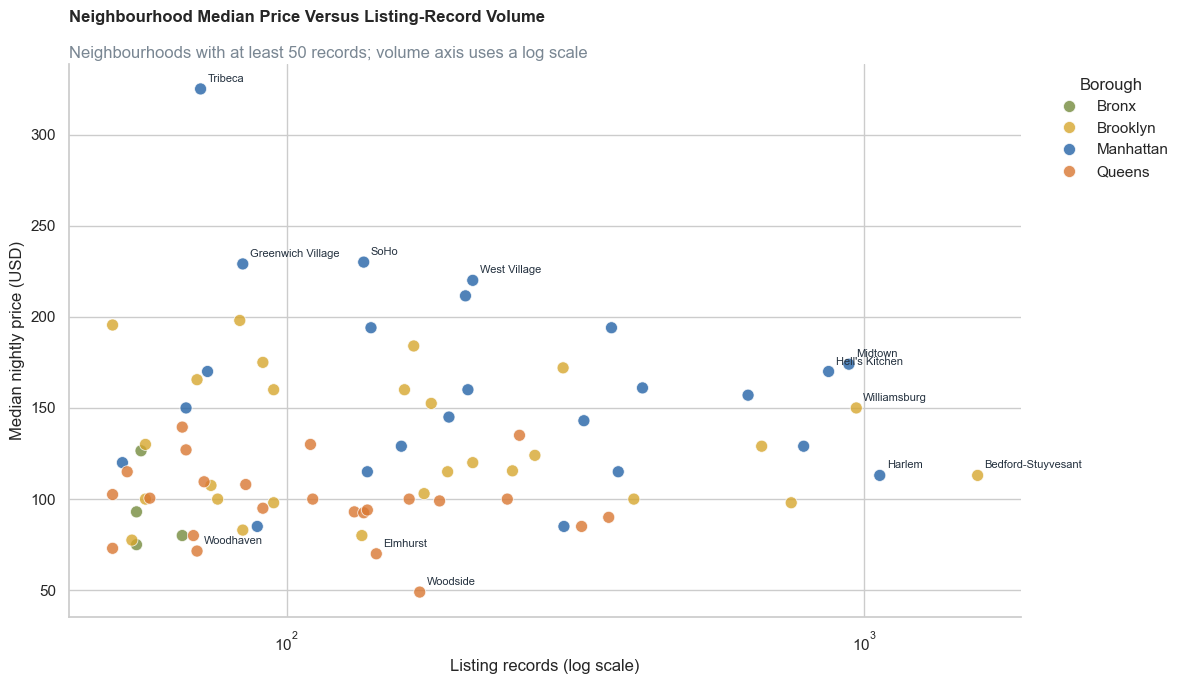

In [14]:
neighbourhood_summary = (
    analysis_df.groupby(["neighbourhood_group", "neighbourhood"], as_index=False)
    .agg(
        records=("id", "size"),
        median_price=("price", "median"),
        median_reviews_ltm=("number_of_reviews_ltm", "median"),
    )
)
established_neighbourhoods = neighbourhood_summary.loc[neighbourhood_summary["records"] >= 50].copy()

plt.figure(figsize=(12, 7))
ax = sns.scatterplot(
    data=established_neighbourhoods,
    x="records",
    y="median_price",
    hue="neighbourhood_group",
    palette=BOROUGH_PALETTE,
    s=75,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.6,
)
ax.set_xscale("log")
ax.set_title("Neighbourhood Median Price Versus Listing-Record Volume", loc="left", fontweight="bold", pad=30)
ax.text(0, 1.01, "Neighbourhoods with at least 50 records; volume axis uses a log scale", transform=ax.transAxes, color=GREY)
ax.set_xlabel("Listing records (log scale)")
ax.set_ylabel("Median nightly price (USD)")

label_rows = pd.concat(
    [
        established_neighbourhoods.nlargest(5, "records"),
        established_neighbourhoods.nlargest(4, "median_price"),
        established_neighbourhoods.nsmallest(3, "median_price"),
    ]
).drop_duplicates("neighbourhood")

for _, row in label_rows.iterrows():
    ax.annotate(
        row["neighbourhood"],
        (row["records"], row["median_price"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        color=INK,
    )

ax.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "neighbourhood_price_volume.png", dpi=180, bbox_inches="tight")
plt.show()

In [15]:
top_volume = neighbourhood_summary.nlargest(10, "records")[
    ["neighbourhood_group", "neighbourhood", "records", "median_price", "median_reviews_ltm"]
]
top_volume_display = top_volume.copy()
top_volume_display["records"] = top_volume_display["records"].map(lambda value: f"{value:,.0f}")
top_volume_display["median_price"] = top_volume_display["median_price"].map(lambda value: f"${value:,.0f}")
top_volume_display["median_reviews_ltm"] = top_volume_display["median_reviews_ltm"].map(lambda value: f"{value:,.1f}")
display(top_volume_display)

,neighbourhood_group,neighbourhood,records,median_price,median_reviews_ltm
50,Brooklyn,Bedford-Stuyvesant,"1,570",$113,5.0
106,Manhattan,Harlem,"1,063",$113,4.0
94,Brooklyn,Williamsburg,968,$150,3.0
113,Manhattan,Midtown,940,$174,2.0
107,Manhattan,Hell's Kitchen,867,$170,2.0
124,Manhattan,Upper East Side,785,$129,2.0
58,Brooklyn,Bushwick,747,$98,3.0
65,Brooklyn,Crown Heights,664,$129,5.0
125,Manhattan,Upper West Side,629,$157,2.0
101,Manhattan,East Village,413,$161,3.0


**Interpretation.** Bedford-Stuyvesant has the largest observed volume (**1,570 records**) with a median price of **$113**. Among neighbourhoods with at least 50 records, Tribeca has the highest median (**$325**), while Woodside is lowest (**$49**). These are descriptive positioning signals, not proof that one neighbourhood is more profitable.

### 6. Geographic distribution

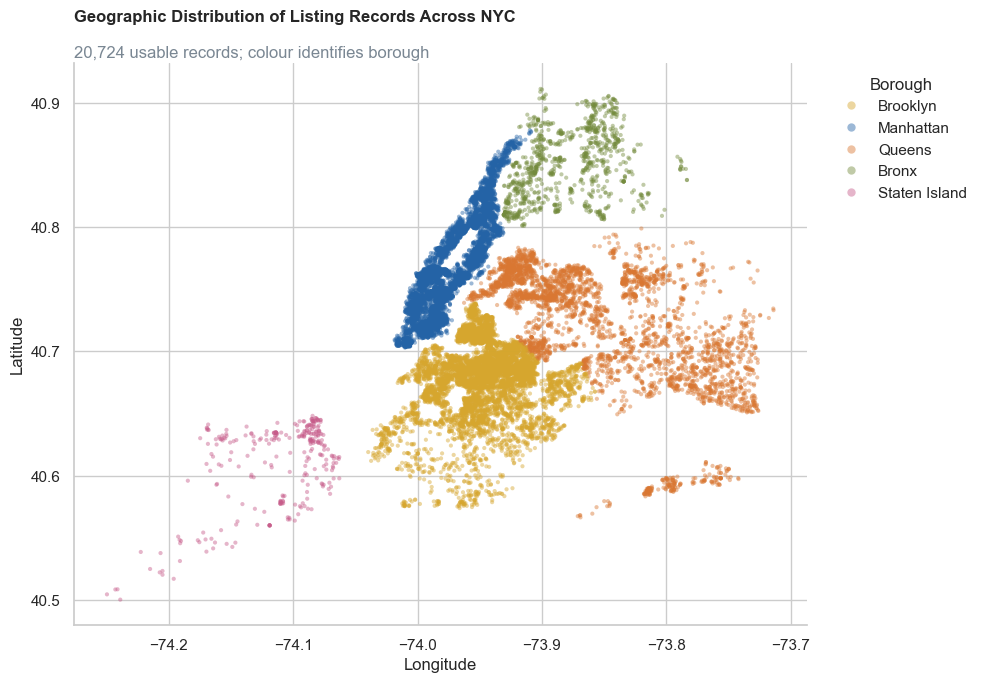

In [16]:
plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    data=analysis_df,
    x="longitude",
    y="latitude",
    hue="neighbourhood_group",
    palette=BOROUGH_PALETTE,
    s=9,
    alpha=0.45,
    linewidth=0,
)
ax.set_title("Geographic Distribution of Listing Records Across NYC", loc="left", fontweight="bold", pad=30)
ax.text(0, 1.01, f"{len(analysis_df):,} usable records; colour identifies borough", transform=ax.transAxes, color=GREY)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, markerscale=2)
ax.set_aspect("equal", adjustable="box")
sns.despine()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "geographic_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

**Interpretation.** The coordinate pattern confirms broad coverage across all five boroughs, with visibly dense clusters in Manhattan and north-western Brooklyn. This supports the earlier volume findings and also validates that the latitude and longitude fields fall within a plausible NYC-area boundary.

### 7. Relationships between price and listing characteristics

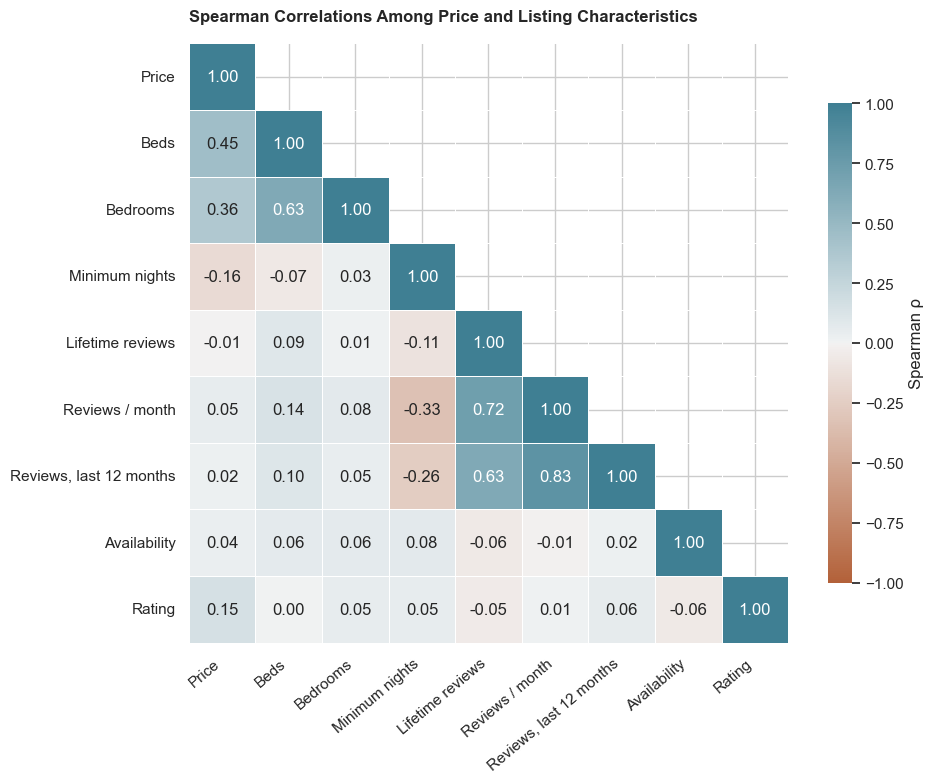

,Spearman ρ
Beds,0.45
Bedrooms,0.36
Minimum nights,-0.16
Rating,0.15
Reviews / month,0.05
Availability,0.04
"Reviews, last 12 months",0.02
Lifetime reviews,-0.01


In [17]:
correlation_columns = {
    "price": "Price",
    "beds": "Beds",
    "bedrooms_numeric": "Bedrooms",
    "minimum_nights": "Minimum nights",
    "number_of_reviews": "Lifetime reviews",
    "reviews_per_month": "Reviews / month",
    "number_of_reviews_ltm": "Reviews, last 12 months",
    "availability_365": "Availability",
    "rating_numeric": "Rating",
}
spearman_corr = analysis_df[list(correlation_columns)].corr(method="spearman").rename(
    index=correlation_columns, columns=correlation_columns
)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool), k=1)
ax = sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=sns.diverging_palette(28, 220, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman ρ", "shrink": 0.8},
)
ax.set_title("Spearman Correlations Among Price and Listing Characteristics", loc="left", fontweight="bold", pad=16)
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "spearman_correlation_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

price_relationships = spearman_corr["Price"].drop("Price").sort_values(key=abs, ascending=False)
display(price_relationships.to_frame("Spearman ρ"))

**Interpretation.** Capacity shows the clearest relationship with price: beds have **ρ = 0.447** and bedrooms **ρ = 0.363**. Rating has only a weak positive association (**ρ = 0.153**). Availability (**ρ = 0.038**) and reviews in the last 12 months (**ρ = 0.022**) are effectively uncorrelated with price in this extract. Correlation is descriptive and does not establish causation.

## Takeaways

### Key findings

1. **Location and room type are essential pricing controls.** Manhattan and entire-home listings carry the highest typical prices, while Bronx and Queens provide lower median benchmarks.
2. **The market is concentrated.** Three-quarters of observed records are in Manhattan and Brooklyn, and a small set of neighbourhoods contributes substantial volume.
3. **Capacity matters more than engagement measures for price.** Beds and bedrooms have the strongest observed price relationships, whereas reviews and availability add little univariate signal.
4. **Minimum-stay rules shape this extract.** With 85.1% of records requiring 30 nights or more, the dataset should not be described as a purely short-stay market view.

### Recommendations

- Benchmark a listing against its **borough, room type, and capacity**, not the citywide average.
- Use **median and interquartile prices** for market positioning; investigate extreme prices before modelling revenue.
- Treat availability and review activity as context, not direct demand or occupancy measures.
- Before forecasting or estimating market size, obtain full-precision listing IDs, a documented snapshot date, booking/occupancy data, and records for listings with zero lifetime reviews.

